In [5]:
import numpy as np #linear algebra
import pandas as pd # data processing
import seaborn as sns

In [6]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [7]:
df_train = pd.read_csv("./twitter_training.csv")
df_val = pd.read_csv("./twitter_validation.csv")

In [8]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column                                                                                                                                                                                                                                              Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                                              --------------  ----- 
 0   3364                                                                                                                                                                                                                                                999 non-null    int64 
 1   Facebook                                                                   

In [9]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column                                                 Non-Null Count  Dtype 
---  ------                                                 --------------  ----- 
 0   2401                                                   74681 non-null  int64 
 1   Borderlands                                            74681 non-null  object
 2   Positive                                               74681 non-null  object
 3   im getting on borderlands and i will murder you all ,  73995 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [10]:
df_train = df_train.rename(columns={'2401': 'ID', 'Borderlands': 'platform', 'Positive': 'sentimen', 'im getting on borderlands and i will murder you all ,': 'text'})
df_val = df_val.rename(columns={'3364': 'ID', 'Facebook': 'platform', 'Irrelevant': 'sentimen', 'I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣': 'text'})

In [11]:
df_train

,ID,platform,sentimen,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [12]:
print(df_train["sentimen"].value_counts())
print(df_val["sentimen"].value_counts())

sentimen
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64
sentimen
Neutral       285
Positive      277
Negative      266
Irrelevant    171
Name: count, dtype: int64


In [13]:
print("Platforms Counts - Training")
print(df_train["platform"].value_counts())
print(20*"==")
print("Platform Counts - Validation")
print(df_val["platform"].value_counts())

Platforms Counts - Training
platform
Microsoft                            2400
MaddenNFL                            2400
TomClancysRainbowSix                 2400
LeagueOfLegends                      2394
CallOfDuty                           2394
Verizon                              2382
CallOfDutyBlackopsColdWar            2376
ApexLegends                          2376
Facebook                             2370
WorldOfCraft                         2364
Dota2                                2364
NBA2K                                2352
TomClancysGhostRecon                 2346
Battlefield                          2346
FIFA                                 2340
Overwatch                            2334
Xbox(Xseries)                        2334
johnson&johnson                      2328
Amazon                               2316
HomeDepot                            2310
PlayStation5(PS5)                    2310
CS-GO                                2304
Cyberpunk2077                        23

In [14]:
# We're dropping unneeded columns

df_train = df_train.drop(["ID","platform"], axis=1)
df_val = df_val.drop(["ID","platform"], axis=1)

In [15]:
df_train

,sentimen,text
0,Positive,I am coming to the borders and I will kill you...
1,Positive,im getting on borderlands and i will kill you ...
2,Positive,im coming on borderlands and i will murder you...
3,Positive,im getting on borderlands 2 and i will murder ...
4,Positive,im getting into borderlands and i can murder y...
...,...,...
74676,Positive,Just realized that the Windows partition of my...
74677,Positive,Just realized that my Mac window partition is ...
74678,Positive,Just realized the windows partition of my Mac ...
74679,Positive,Just realized between the windows partition of...


In [16]:
df_val

,sentimen,text
0,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,Negative,@Microsoft Why do I pay for WORD when it funct...
2,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,Neutral,Now the President is slapping Americans in the...
4,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...
994,Irrelevant,⭐️ Toronto is the arts and culture capital of ...
995,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
996,Positive,Today sucked so it’s time to drink wine n play...
997,Positive,Bought a fraction of Microsoft today. Small wins.


In [17]:
print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")
print(f"Duplicates: {df_train.duplicated().sum()}") 
print(f"missing data: {sum(df_train.isna().sum())}")

print(20*"==")

print(f"Rows: {df_val.shape[0]}, Columns: {df_val.shape[1]}")
print(f"Duplicates: {df_val.duplicated().sum()}") 
print(f"missing data: {sum(df_val.isna().sum())}")

Rows: 74681, Columns: 2
Duplicates: 4909
missing data: 686
Rows: 999, Columns: 2
Duplicates: 1
missing data: 0

Duplicates: 4909
missing data: 686
Rows: 999, Columns: 2
Duplicates: 1
missing data: 0


In [18]:
kolom1=len(df_train.columns)
for i in range (0, kolom1):
  df_train=df_train[df_train.iloc[:,i]!='?']
  df_train=df_train[df_train.iloc[:,i]!='']
  df_train=df_train[~df_train.iloc[:,i].isna()]
df_train.info()
df_train.drop_duplicates(keep= 'first',inplace = True)

kolom=len(df_val.columns)
for i in range (0, kolom):
  df_val=df_val[df_val.iloc[:,i]!='?']
  df_val=df_val[df_val.iloc[:,i]!='']
  df_val=df_val[~df_val.iloc[:,i].isna()]
df_val.info()
df_val.drop_duplicates(keep= 'first',inplace = True)

print(f"Rows: {df_train.shape[0]}, Columns: {df_train.shape[1]}")
print(f"Duplicates: {df_train.duplicated().sum()}") 
print(f"missing data: {sum(df_train.isna().sum())}")

print(20*"==")

print(f"Rows: {df_val.shape[0]}, Columns: {df_val.shape[1]}")
print(f"Duplicates: {df_val.duplicated().sum()}") 
print(f"missing data: {sum(df_val.isna().sum())}")

<class 'pandas.core.frame.DataFrame'>
Index: 73995 entries, 0 to 74680
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentimen  73995 non-null  object
 1   text      73995 non-null  object
dtypes: object(2)
memory usage: 1.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentimen  999 non-null    object
 1   text      999 non-null    object
dtypes: object(2)
memory usage: 15.7+ KB
Rows: 69768, Columns: 2
Duplicates: 0
missing data: 0
Rows: 998, Columns: 2
Duplicates: 0
missing data: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentimen  999 non-null    object
 1   text      999 non-null    object
dtypes: object(2)
memory usage: 15.7+ KB
Rows:

In [19]:
%pip install emoji

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
import re
import string
import emoji
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# Pastikan resource NLTK terunduh
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')           # kalau belum pernah diunduh
nltk.download('omw-1.4')           # opsional tapi sering diperlukan
nltk.download('punkt')             # untuk tokenisasi, jika kamu pakai word_tokenize()

# Inisialisasi
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Kamus singkatan umum (bisa diperluas)
abbreviation_map = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "btw": "by the way",
    "idk": "i do not know",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "lol": "laughing out loud",
    "omg": "oh my god",
    "thx": "thanks",
    "pls": "please",
    "plz": "please",
    "dont": "do not",
    "cant": "cannot",
    "wont": "will not",
    "ive": "i have",
    "ill": "i will",
    "didnt": "did not",
    "doesnt": "does not",
    "isnt": "is not",
    "wasnt": "was not",
    "havent": "have not",
    "shouldnt": "should not",
    "couldnt": "could not",
    "wouldnt": "would not",
}

def get_wordnet_pos(word):
    """
    Helper function: 
    Mengubah POS tag (part-of-speech) menjadi format yang bisa dipakai lemmatizer.
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)


def preprocess_text(text):
    """
    Function for text preprocessing for English sentiment analysis.
    Includes:
      - lowercase
      - emoji handling
      - URL and number removal
      - punctuation removal
      - short form expansion
      - stopword removal
      - lemmatization
    """

    # Ensure input is string
    if not isinstance(text, str):
        text = str(text)

    # Lowercase
    text = text.lower()

    # Replace emojis with text description
    text = emoji.demojize(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Expand common short forms
    words = text.split()
    expanded_words = [abbreviation_map.get(w, w) for w in words]
    text = ' '.join(expanded_words)

    # Tokenize and remove stopwords + lemmatize
    filtered_words = []
    for word in text.split():
        if word not in stop_words:
            pos = get_wordnet_pos(word)
            lemma = lemmatizer.lemmatize(word, pos)
            filtered_words.append(lemma)

    # Join cleaned text
    processed_text = ' '.join(filtered_words)

    # Clean extra whitespace
    processed_text = re.sub(r'\s+', ' ', processed_text).strip()

    return processed_text

[nltk_data] Downloading package stopwords to C:\Users\Asus
[nltk_data]     Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Asus
[nltk_data]     Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Asus Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Asus Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to C:\Users\Asus
[nltk_data]     Vivobook\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\As

In [21]:
df_train['clean_text'] = df_train['text'].apply(preprocess_text)
print(df_train[['text', 'clean_text']])

                                                    text  \
0      I am coming to the borders and I will kill you...   
1      im getting on borderlands and i will kill you ...   
2      im coming on borderlands and i will murder you...   
3      im getting on borderlands 2 and i will murder ...   
4      im getting into borderlands and i can murder y...   
...                                                  ...   
74676  Just realized that the Windows partition of my...   
74677  Just realized that my Mac window partition is ...   
74678  Just realized the windows partition of my Mac ...   
74679  Just realized between the windows partition of...   
74680  Just like the windows partition of my Mac is l...   

                                              clean_text  
0                                       come border kill  
1                                 im get borderland kill  
2                              im come borderland murder  
3                               im get bord

In [22]:
df_train

,sentimen,text,clean_text
0,Positive,I am coming to the borders and I will kill you...,come border kill
1,Positive,im getting on borderlands and i will kill you ...,im get borderland kill
2,Positive,im coming on borderlands and i will murder you...,im come borderland murder
3,Positive,im getting on borderlands 2 and i will murder ...,im get borderland murder
4,Positive,im getting into borderlands and i can murder y...,im get borderland murder
...,...,...,...
74676,Positive,Just realized that the Windows partition of my...,realize window partition mac like year behind ...
74677,Positive,Just realized that my Mac window partition is ...,realize mac window partition year behind nvidi...
74678,Positive,Just realized the windows partition of my Mac ...,realize window partition mac year behind nvidi...
74679,Positive,Just realized between the windows partition of...,realize window partition mac like year behind ...


In [23]:
%pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


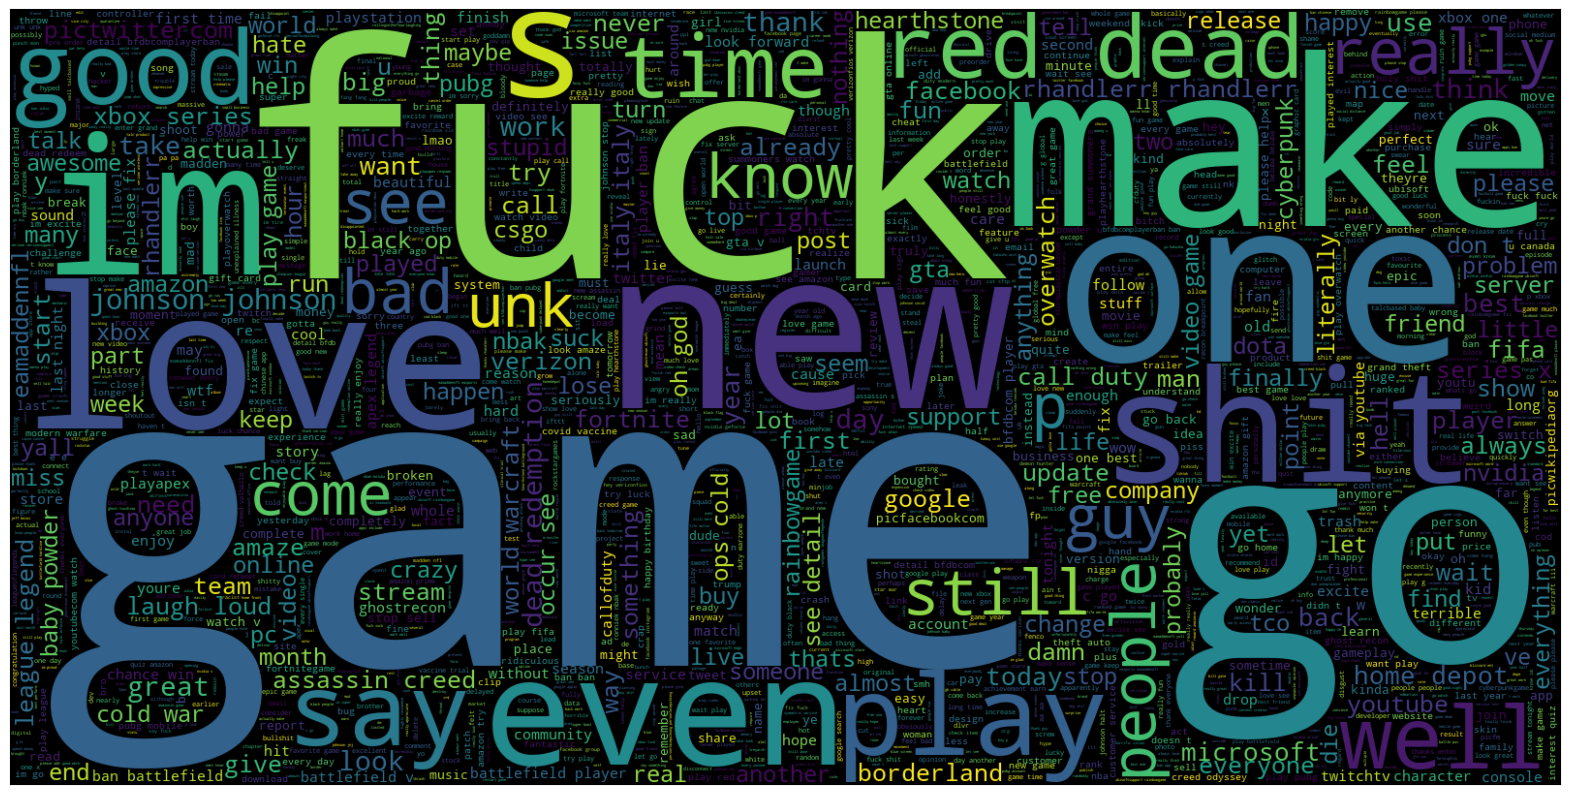

In [24]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS
plt.figure(figsize=(20, 20))
wc = WordCloud(max_words=2000, width=1600, height=800, stopwords=STOPWORDS).generate(' '.join(df_train['clean_text']))
plt.imshow(wc, interpolation='bilinear')
plt.xticks([])
plt.yticks([])
plt.show()

In [25]:
df_val['clean_text'] = df_val['text'].apply(preprocess_text)
print(df_val[['text', 'clean_text']])

                                                  text  \
0    BBC News - Amazon boss Jeff Bezos rejects clai...   
1    @Microsoft Why do I pay for WORD when it funct...   
2    CSGO matchmaking is so full of closet hacking,...   
3    Now the President is slapping Americans in the...   
4    Hi @EAHelp I’ve had Madeleine McCann in my cel...   
..                                                 ...   
994  ⭐️ Toronto is the arts and culture capital of ...   
995  tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...   
996  Today sucked so it’s time to drink wine n play...   
997  Bought a fraction of Microsoft today. Small wins.   
998  Johnson & Johnson to stop selling talc baby po...   

                                            clean_text  
0    bbc news amazon bos jeff bezos reject claim co...  
1    microsoft pay word function poorly samsungus c...  
2    csgo matchmaking full closet hack truly awful ...  
3    president slap american face really commit unl...  
4    hi eahelp i’v

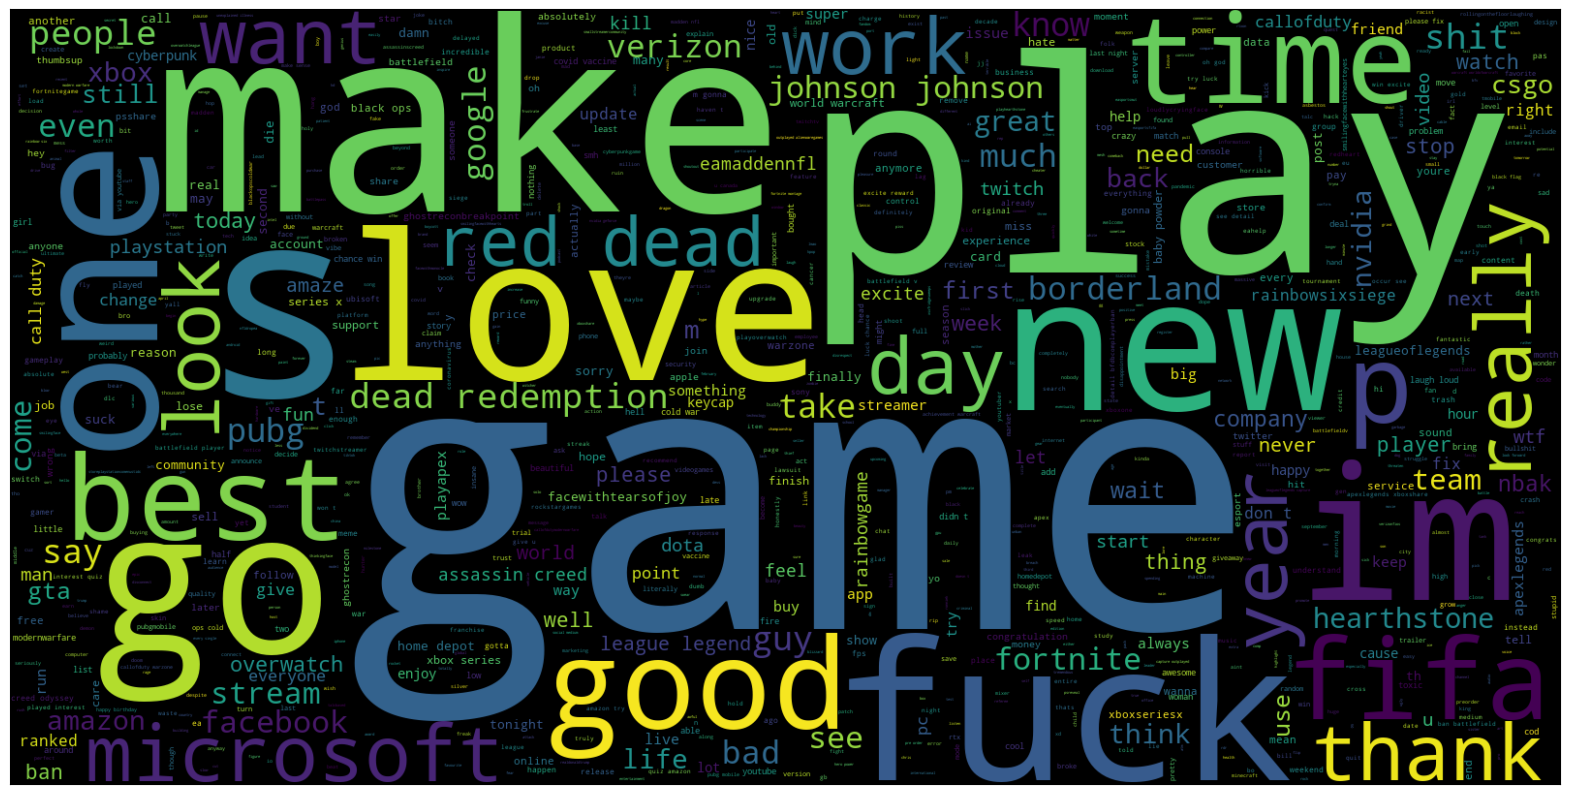

In [26]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud,STOPWORDS
plt.figure(figsize=(20, 20))
wc = WordCloud(max_words=2000, width=1600, height=800, stopwords=STOPWORDS).generate(' '.join(df_val['clean_text']))
plt.imshow(wc, interpolation='bilinear')
plt.xticks([])
plt.yticks([])
plt.show()

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Define TF-IDF vectorizer (you can tune max_features, ngram_range etc. as needed)
tfidf = TfidfVectorizer(max_features=17000, ngram_range=(1,2))

In [28]:
# Fit TF-IDF on training text and transform train and test text
X_train = tfidf.fit_transform(df_train['clean_text'])
X_test = tfidf.transform(df_val['clean_text'])

# Assuming your sentiment labels are in 'label' column in both dfs
y_train = df_train['sentimen']
y_test = df_val['sentimen']

In [39]:
from sklearn.metrics import roc_curve, auc, roc_auc_score, accuracy_score, f1_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import inspect

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluasi model klasifikasi multi-class dan binary. Perbaikan:
      - Gunakan urutan kelas dari model jika tersedia (menghindari mismatch kolom probabilitas),
      - Tangani decision_function/predict_proba 1-D (binary) dengan konversi ke 2-kolom.
    """

    # Prediksi label
    y_pred = model.predict(X_test)

    # Coba ambil skor probabilitas atau decision function
    if hasattr(model, "decision_function"):
        decision_scores = model.decision_function(X_test)
    elif hasattr(model, "predict_proba"):
        decision_scores = model.predict_proba(X_test)
    else:
        raise ValueError(f"Model {model_name} tidak mendukung ROC (butuh decision_function atau predict_proba)")

    # Tentukan kelas untuk binarisasi: prefer model.classes_ jika ada
    classes = getattr(model, 'classes_', np.unique(y_test))
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes = y_test_bin.shape[1]

    # Normalisasi bentuk decision_scores agar cocok dengan n_classes
    if isinstance(decision_scores, np.ndarray) and decision_scores.ndim == 1:
        # Binary case: ubah menjadi two-column [1-p, p]
        decision_scores = np.vstack([1 - decision_scores, decision_scores]).T

    # Jika decision_scores 2-D tetapi kolomnya tidak cocok dengan n_classes, coba reorder sesuai model.classes_ jika memungkinkan
    if hasattr(decision_scores, 'ndim') and decision_scores.ndim == 2 and decision_scores.shape[1] != n_classes:
        if hasattr(model, 'classes_'):
            model_classes = list(model.classes_)
            try:
                idx = [model_classes.index(c) for c in classes]
                decision_scores = decision_scores[:, idx]
            except Exception:
                # Kalau gagal, biarkan seperti semula dan lanjutkan (mungkin shapes cocok saat dieksekusi)
                pass

    # Hitung ROC curve dan AUC untuk tiap kelas
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], decision_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # AUC rata-rata (macro)
    roc_auc["macro"] = roc_auc_score(y_test_bin, decision_scores, average="macro", multi_class="ovr")

    # Akurasi dan F1-score
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"======= Evaluasi Klasifikasi {model_name} =======")
    print(f"Akurasi Klasifikasi     : {accuracy * 100:.2f}%")
    print(f"F-measure (macro avg)   : {f1:.3f}")
    print(f"AUC rata-rata (macro)   : {roc_auc['macro']:.3f}")
    print("=" * 45)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'orange', 'red', 'purple', 'brown']

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    # Garis diagonal (baseline)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for Multi-Class {model_name}')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "f1_macro": f1,
        "auc_macro": roc_auc["macro"]
    }

In [30]:
# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Accuracy: 0.8987975951903807
Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.90      0.87      0.88       171
    Negative       0.87      0.94      0.90       266
     Neutral       0.94      0.87      0.90       285
    Positive       0.89      0.91      0.90       276

    accuracy                           0.90       998
   macro avg       0.90      0.90      0.90       998
weighted avg       0.90      0.90      0.90       998



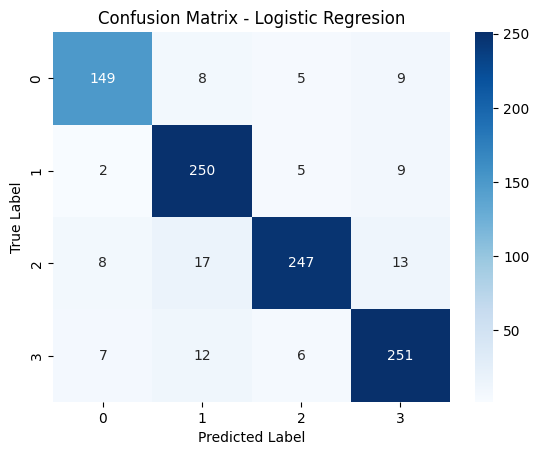

In [31]:
# Predict on test data
y_predlr = model.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_predlr))
print("Classification Report:\n", classification_report(y_test, y_predlr))

cm = confusion_matrix(y_test, y_predlr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regresion')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

======= Evaluasi Klasifikasi Logistic Regresion =======
Akurasi Klasifikasi     : 89.88%
F-measure (macro avg)   : 0.897
AUC rata-rata (macro)   : 0.973


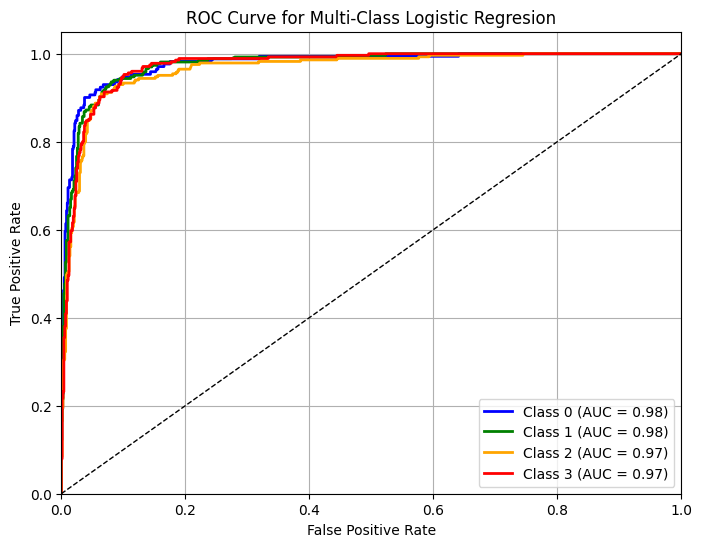

In [32]:
lr_results = evaluate_model(model, X_test, y_test, model_name="Logistic Regresion")

In [33]:
### Tugas
#Training Menggunakan Model Random Forest dan SVM
# Opsional : Training menggunakan XGBoost

Random Forest Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.99      0.96      0.97       171
    Negative       0.95      0.97      0.96       266
     Neutral       0.96      0.95      0.96       285
    Positive       0.96      0.97      0.96       276

    accuracy                           0.96       998
   macro avg       0.96      0.96      0.96       998
weighted avg       0.96      0.96      0.96       998



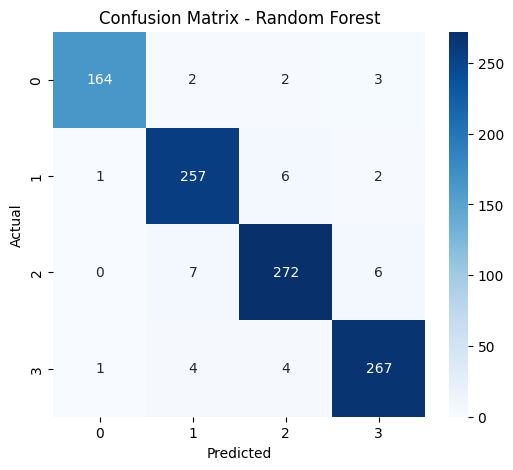

======= Evaluasi Klasifikasi Random Forest =======
Akurasi Klasifikasi     : 96.19%
F-measure (macro avg)   : 0.963
AUC rata-rata (macro)   : 0.998


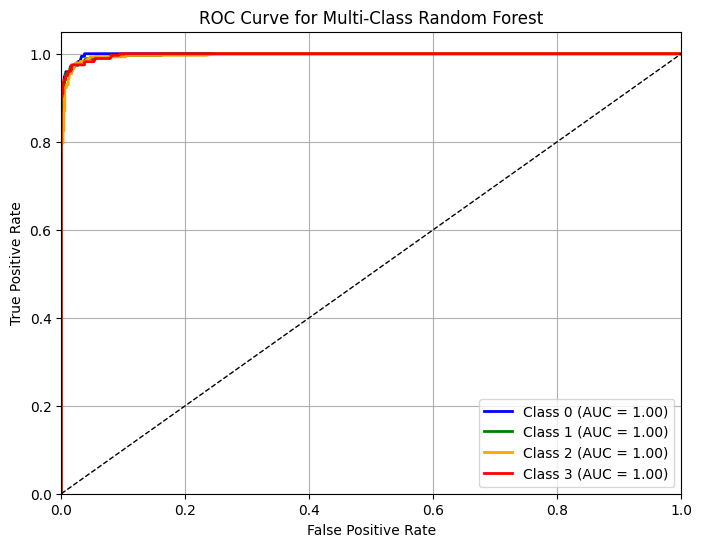

{'model': 'Random Forest',
 'accuracy': 0.9619238476953907,
 'f1_macro': 0.9630527945717237,
 'auc_macro': 0.9978339657879735}

In [34]:
# Import tambahan untuk training dan evaluasi
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest Classification Report:\n', classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluate with the existing helper (prints ROC/AUC etc.)
rf_results = evaluate_model(rf, X_test, y_test, model_name='Random Forest')
# Save model
joblib.dump(rf, 'rf_model.joblib')
rf_results

SVM Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.95      0.91      0.93       171
    Negative       0.91      0.95      0.93       266
     Neutral       0.94      0.91      0.93       285
    Positive       0.91      0.93      0.92       276

    accuracy                           0.93       998
   macro avg       0.93      0.92      0.93       998
weighted avg       0.93      0.93      0.93       998



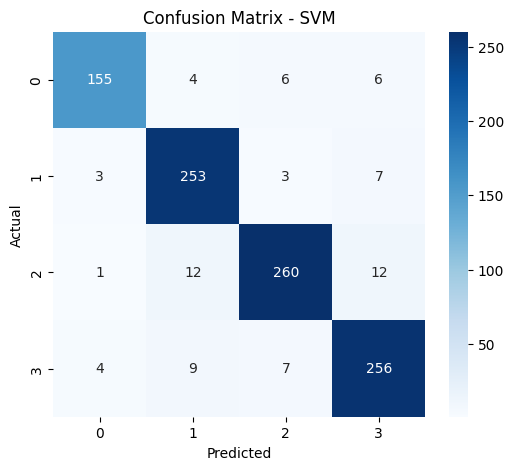

======= Evaluasi Klasifikasi SVM =======
Akurasi Klasifikasi     : 92.59%
F-measure (macro avg)   : 0.926
AUC rata-rata (macro)   : 0.977


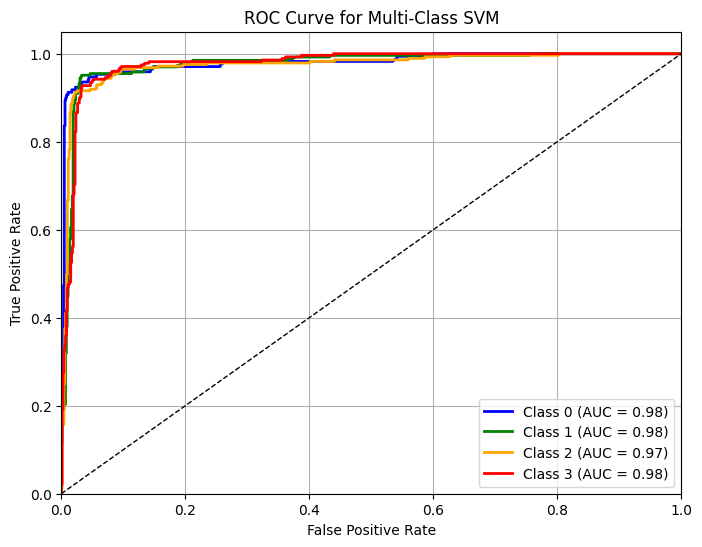

{'model': 'SVM',
 'accuracy': 0.9258517034068137,
 'f1_macro': 0.9261042615730529,
 'auc_macro': 0.9770593575089731}

In [35]:
# SVM (Support Vector Machine) - with probability=True to support ROC/AUC
svm = SVC(kernel='linear', probability=True, random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print('SVM Classification Report:\n', classification_report(y_test, y_pred_svm))
cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

svm_results = evaluate_model(svm, X_test, y_test, model_name='SVM')
joblib.dump(svm, 'svm_model.joblib')
svm_results

In [36]:
# Install xgboost if not available (kept as a separate cell so user can re-run if needed)
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/72.0 MB 3.9 MB/s eta 0:00:19
    --------------------------------------- 1.3/72.0 MB 3.2 MB/s eta 0:00:22
   - -------------------------------------- 1.8/72.0 MB 3.5 MB/s eta 0:00:21
   - -------------------------------------- 2.1/72.0 MB 3.2 MB/s eta 0:00:22
   - -------------------------------------- 2.4/72.0 MB 2.5 MB/s eta 0:00:28
   - -------------------------------------- 2.9/72.0 MB 2.3 MB/s eta 0:00:31
   - -------------------------------------- 3.4/72.0 MB 2.4 MB/s eta 0:00:29
   -- ------------------------------------- 3.7/72.0 MB 2.3 MB/s eta 0:00:30
   -- ------------------------------------- 4.7/72.0 MB 2.4 MB/s eta 0:00:28
   --- ------------------------------------ 5.8/72.0 MB 2.7 MB/s eta 0:00:25
   --- ------------------------------------ 6.8/72.0 MB 2.9 MB/s eta 0:00:23
   --

C:\Users\Asus Vivobook\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [05:39:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classification Report:
               precision    recall  f1-score   support

  Irrelevant       0.89      0.73      0.80       171
    Negative       0.73      0.89      0.80       266
     Neutral       0.86      0.72      0.78       285
    Positive       0.81      0.87      0.84       276

    accuracy                           0.81       998
   macro avg       0.82      0.80      0.81       998
weighted avg       0.82      0.81      0.81       998



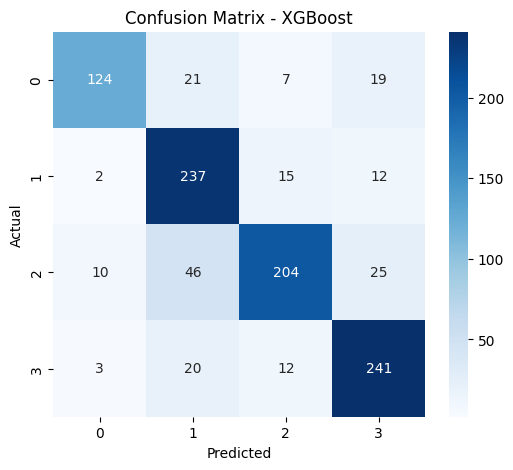

======= Evaluasi Klasifikasi XGBoost =======
Akurasi Klasifikasi     : 80.76%
F-measure (macro avg)   : 0.806
AUC rata-rata (macro)   : 0.957


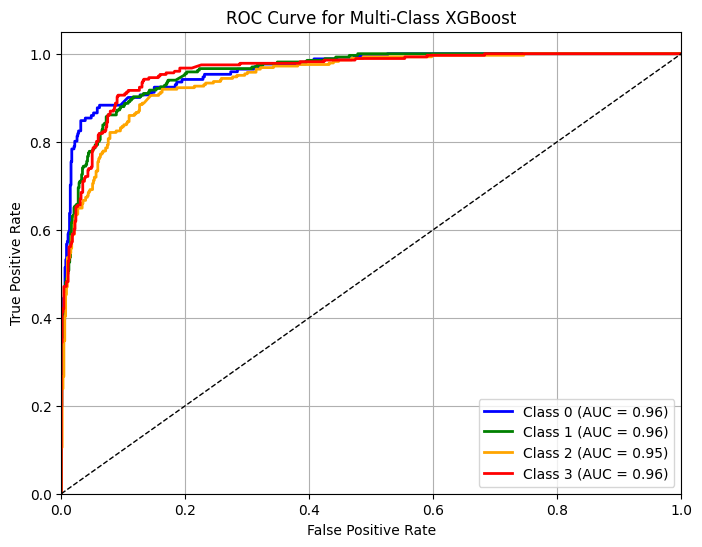

{'model': 'XGBoost',
 'accuracy': 0.8076152304609219,
 'f1_macro': 0.8061728224341288,
 'auc_macro': 0.9568838952353262}

In [41]:
# XGBoost training and evaluation (encode labels to numeric to avoid label-shape issues)
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels (if any) to integers - XGBoost prefers numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# XGBoost - train on encoded labels
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=200, random_state=42)
xgb.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb.predict(X_test)
# Convert predictions back to original label strings for readable reports
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)
print('XGBoost Classification Report:\n', classification_report(y_test, y_pred_xgb))
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Evaluate using encoded true labels so evaluate_model's binarization matches model.classes_
xgb_results = evaluate_model(xgb, X_test, y_test_enc, model_name='XGBoost')
# Save model and label encoder so you can inverse transform later
joblib.dump(xgb, 'xgb_model.joblib')
joblib.dump(le, 'xgb_label_encoder.joblib')
xgb_results